# EXPT NO: 6
# IMPLEMENTATION OF LSTM FOR SENTIMENT ANALYSIS

**Name:** Jeevanantham K
**Roll No:** 24BAD047  
**Department:** AI & DS  

**Aim:** To implement a Long Short-Term Memory (LSTM) network for sentiment analysis by performing text preprocessing, tokenization, sequence generation and embedding, and to classify movie reviews as positive or negative.

**Dataset:** IMDB Movie Reviews (50,000 labelled reviews, Stanford aclImdb). A random subset is used so that training finishes quickly in Google Colab.


## SETUP – Libraries, random seed and settings
All libraries are imported here. A fixed random seed (42) is used so that the results are reasonably reproducible. The settings (vocabulary size, sequence length, etc.) are kept in one place so they are easy to explain in viva.

In [22]:
# ==================== SETUP ====================
import os, re, random, datetime, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from collections import Counter
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Fixed random seed -> reasonably reproducible results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ---- Settings used in the whole experiment ----
N_TRAIN_SUBSET = 20000   # reviews used from the 25,000 training reviews
N_TEST_SUBSET  = 5000    # reviews used from the 25,000 test reviews
VOCAB_SIZE     = 10000   # vocabulary size (index 0 = padding, 1 = unknown word)
MAXLEN         = 200     # every review is padded / cut to 200 tokens
EMBED_DIM      = 64      # size of each word vector
LSTM_UNITS     = 64      # number of LSTM memory units
BATCH_SIZE     = 64
EPOCHS         = 10

def student_info(section):
    print("=" * 60)
    print("Name       : Jeevanantham K")
    print("Roll No    : 24BAD047")
    print("Department : AI & DS")
    print("Experiment : 6 – LSTM Sentiment Analysis")
    print("Section    :", section)
    print("Run time   :", datetime.datetime.now().strftime("%d-%m-%Y %H:%M:%S"))
    print("=" * 60)

student_info("Setup")
print("TensorFlow version :", tf.__version__)
print("GPU available      :", tf.config.list_physical_devices("GPU"))

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : Setup
Run time   : 30-09-2026 12:35:22
TensorFlow version : 2.20.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## PART A – DATASET PREPARATION AND TEXT PREPROCESSING

**Steps performed in this part**
1. Load the IMDB movie-review dataset and explore it (samples, shapes, class distribution).
2. Clean the text: lowercase, remove HTML tags / punctuation / special characters, remove stop words.
3. Tokenize each review into words.
4. Build a vocabulary from the **training** reviews only (avoids data leakage).
5. Convert tokens to numbers and pad every review to the same length.
6. Encode labels (negative = 0, positive = 1) and split into training / validation / test sets.

*Note:* the stop-word list is modified so that negation words such as *not* and *no* are **kept**, because they change the meaning of a sentence ("not good").

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART A – Load and explore dataset
Run time   : 30-09-2026 12:35:22
Dataset loaded from the Stanford aclImdb archive.

Full training set shape : (25000, 2)
Full test set shape     : (25000, 2)
Training subset shape   : (20000, 2)
Test subset shape       : (5000, 2)
Total samples used      : 25000

Class distribution (training subset):
sentiment
negative    10038
positive     9962
Name: count, dtype: int64

Class distribution (test subset):
sentiment
negative    2515
positive    2485
Name: count, dtype: int64

--- Sample POSITIVE review (original) ---
This movie really rocks! Jeff Wincott is terrific in the film! His fighting incredible! He is such a fast martial artist! Brigitte Nielsen & Matthias Hues was very good! Mission of Justice is an action packed movie that is never boring! If you like fighting movies with incredible non stop action then check out Mission

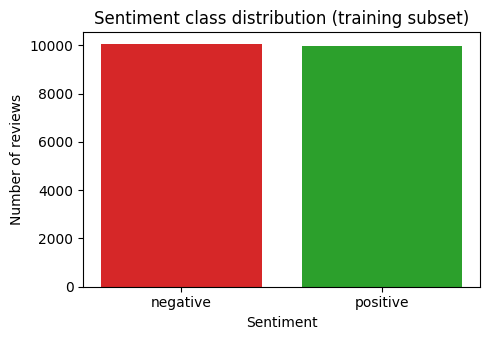

In [23]:
# ==================== PART A (1/2): LOAD AND EXPLORE THE DATASET ====================
student_info("PART A – Load and explore dataset")

def load_imdb_from_stanford():
    url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
    fpath = keras.utils.get_file("aclImdb_v1.tar.gz", origin=url, extract=True,
                                 cache_dir=".", cache_subdir="datasets")
    base = fpath if os.path.isdir(fpath) else os.path.dirname(fpath)
    root = base if os.path.basename(base) == "aclImdb" else os.path.join(base, "aclImdb")

    def read_split(split):
        texts, labels = [], []
        for lab in ["neg", "pos"]:
            folder = os.path.join(root, split, lab)
            for fname in os.listdir(folder):
                with open(os.path.join(folder, fname), encoding="utf-8") as f:
                    texts.append(f.read())
                labels.append("positive" if lab == "pos" else "negative")
        return pd.DataFrame({"review": texts, "sentiment": labels})

    return read_split("train"), read_split("test")

def load_imdb_from_tfds():          # backup option if the first download fails
    import tensorflow_datasets as tfds
    out = []
    for split in ["train", "test"]:
        d = tfds.as_numpy(tfds.load("imdb_reviews", split=split, batch_size=-1))
        texts = [t.decode("utf-8") for t in d["text"]]
        labels = ["positive" if l == 1 else "negative" for l in d["label"]]
        out.append(pd.DataFrame({"review": texts, "sentiment": labels}))
    return out[0], out[1]

try:
    full_train_df, full_test_df = load_imdb_from_stanford()
    print("Dataset loaded from the Stanford aclImdb archive.")
except Exception as e:
    print("Stanford download failed:", e)
    print("Trying tensorflow_datasets instead ...")
    full_train_df, full_test_df = load_imdb_from_tfds()

print("\nFull training set shape :", full_train_df.shape)
print("Full test set shape     :", full_test_df.shape)

# Use a random subset to keep training fast in Colab
train_pool_df = full_train_df.sample(n=N_TRAIN_SUBSET, random_state=SEED).reset_index(drop=True)
test_df = full_test_df.sample(n=N_TEST_SUBSET, random_state=SEED).reset_index(drop=True)
print("Training subset shape   :", train_pool_df.shape)
print("Test subset shape       :", test_df.shape)
print("Total samples used      :", len(train_pool_df) + len(test_df))

print("\nClass distribution (training subset):")
print(train_pool_df["sentiment"].value_counts())
print("\nClass distribution (test subset):")
print(test_df["sentiment"].value_counts())

for lab in ["positive", "negative"]:
    print(f"\n--- Sample {lab.upper()} review (original) ---")
    print(train_pool_df[train_pool_df["sentiment"] == lab]["review"].iloc[0][:400], "...")

print("\nReview length in words (training subset):")
print(train_pool_df["review"].str.split().str.len().describe().round(1))

counts = train_pool_df["sentiment"].value_counts().reindex(["negative", "positive"])
plt.figure(figsize=(5, 3.5))
plt.bar(counts.index, counts.values, color=["tab:red", "tab:green"])
plt.title("Sentiment class distribution (training subset)")
plt.xlabel("Sentiment"); plt.ylabel("Number of reviews")
plt.tight_layout(); plt.show()

In [24]:
# ==================== PART A (2/2): PREPROCESSING, TOKENIZATION, PADDING, SPLIT ====================
student_info("PART A – Preprocessing, tokenization, padding, split")
import nltk

# ---- Stop words (NLTK) ----
try:
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    STOP_WORDS = set(stopwords.words("english"))
except Exception:
    STOP_WORDS = {"the","a","an","and","or","is","are","was","were","of","to","in","it","this",
                  "that","i","you","he","she","they","we","for","on","with","as","at","by","be","but","from"}
# Keep negation words because they change the sentiment ("not good")
KEEP_WORDS = {"not","no","nor","don","didn","doesn","isn","wasn","weren","aren","couldn","wouldn",
              "shouldn","hadn","hasn","haven","won","ain","mustn","needn","shan","mightn"}
STOP_WORDS = STOP_WORDS - KEEP_WORDS
print("Number of stop words removed:", len(STOP_WORDS))

# ---- Cleaning function ----
def clean_text(text):
    text = text.lower()                          # 1. lowercase
    text = re.sub(r"<[^>]+>", " ", text)         # 2. remove HTML tags such as <br />
    text = re.sub(r"[^a-z\s]", " ", text)        # 3. remove punctuation, digits, special characters
    words = [w for w in text.split() if w not in STOP_WORDS]   # 4. remove stop words
    return " ".join(words)

# ---- Split: 80% train, 20% validation (test set is kept separate) ----
train_df, val_df = train_test_split(train_pool_df, test_size=0.2, random_state=SEED,
                                    stratify=train_pool_df["sentiment"])
train_df = train_df.reset_index(drop=True).copy()
val_df = val_df.reset_index(drop=True).copy()

# ---- Encode labels: negative -> 0, positive -> 1 ----
label_map = {"negative": 0, "positive": 1}
for d in (train_df, val_df, test_df):
    d["label"] = d["sentiment"].map(label_map)

# ---- Clean and tokenize ----
for d in (train_df, val_df, test_df):
    d["clean_review"] = d["review"].apply(clean_text)
    d["tokens"] = d["clean_review"].str.split()

# ---- Build vocabulary from TRAINING reviews only ----
PAD_INDEX, OOV_INDEX = 0, 1
word_counts = Counter(tok for toks in train_df["tokens"] for tok in toks)
print("Unique words in training reviews:", len(word_counts))
most_common = word_counts.most_common(VOCAB_SIZE - 2)
word_index = {word: i + 2 for i, (word, _) in enumerate(most_common)}   # 0=PAD, 1=OOV
index_word = {i: w for w, i in word_index.items()}

# ---- Tokens -> numbers -> padded sequences ----
def tokens_to_padded(token_lists):
    seqs = [[word_index.get(w, OOV_INDEX) for w in toks] for toks in token_lists]
    return keras.utils.pad_sequences(seqs, maxlen=MAXLEN, padding="pre",
                                     truncating="post", value=PAD_INDEX)

def encode_texts(texts):             # used later for predicting new reviews
    return tokens_to_padded([clean_text(t).split() for t in texts])

X_train = tokens_to_padded(train_df["tokens"]);  y_train = train_df["label"].values.astype("float32")
X_val   = tokens_to_padded(val_df["tokens"]);    y_val   = val_df["label"].values.astype("float32")
X_test  = tokens_to_padded(test_df["tokens"]);   y_test  = test_df["label"].values.astype("float32")

# ---------------- OUTPUT ----------------
print("\n----- Original vs preprocessed reviews -----")
for i in range(2):
    print(f"\nReview {i} | Sentiment: {train_df['sentiment'][i]} | Label: {train_df['label'][i]}")
    print("ORIGINAL    :", train_df["review"][i][:200], "...")
    print("PREPROCESSED:", train_df["clean_review"][i][:200], "...")

print("\n----- Tokenization and numerical sequence (Review 0) -----")
print("Tokens (first 12)       :", train_df["tokens"][0][:12])
print("Numbers (first 12)      :", [word_index.get(w, OOV_INDEX) for w in train_df["tokens"][0][:12]])
print("Length before padding   :", len(train_df["tokens"][0]))
print("Padded sequence (first 15 values):", X_train[0][:15])
print("Padded sequence (last 15 values) :", X_train[0][-15:])
print("Last 10 ids decoded back to words:", [index_word.get(i, "<pad>" if i == 0 else "<unk>") for i in X_train[0][-10:]])

print("\n----- Vocabulary -----")
print("Vocabulary size (VOCAB_SIZE)      :", VOCAB_SIZE)
print("10 most frequent words            :", list(word_index.items())[:10])

print("\n----- Shapes -----")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "| y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "| y_test :", y_test.shape)
print("Padded sequence shape per review :", X_train.shape[1:])

print("\n----- Class distribution after split (0 = negative, 1 = positive) -----")
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:10s} -> negative: {int((y == 0).sum())}, positive: {int((y == 1).sum())}")

# Sanity checks (no shape mismatch)
assert X_train.shape[0] == len(y_train) and X_val.shape[0] == len(y_val) and X_test.shape[0] == len(y_test)
assert X_train.shape[1] == MAXLEN and X_train.max() < VOCAB_SIZE
print("\nSanity checks passed: shapes match and all word ids are < VOCAB_SIZE.")

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART A – Preprocessing, tokenization, padding, split
Run time   : 30-09-2026 12:36:00
Number of stop words removed: 176
Unique words in training reviews: 61519

----- Original vs preprocessed reviews -----

Review 0 | Sentiment: positive | Label: 1
ORIGINAL    : TIGERLAND / (2000) ***1/2 (out of four)<br /><br />By Blake French:<br /><br />	Throughout the years audiences have seen and understood war films with every point of view possible, and somehow produce ...
PREPROCESSED: tigerland four blake french throughout years audiences seen understood war films every point view possible somehow producers writers always come new innovative methods portraying various soldiers batt ...

Review 1 | Sentiment: negative | Label: 0
ORIGINAL    : If you like bad movies, this is the one to see. It's incredibly low-budget special effects (you'll see what I mean) and use of non-

## PART B – EMBEDDING GENERATION

A neural network cannot understand words, only numbers. The Keras **Embedding layer** is a lookup table with `VOCAB_SIZE` rows and `EMBED_DIM` columns. Each word id selects one row, which is that word's **dense vector**.

- Input shape  : `(batch_size, MAXLEN)` – integer word ids
- Output shape : `(batch_size, MAXLEN, EMBED_DIM)` – one vector per word

In the embedding space, words are points (vectors). At the start the vectors are random. During training the vectors are updated, so words used in similar contexts (e.g. *good*, *great*) move closer to each other.

In [25]:
# ==================== PART B: EMBEDDING GENERATION ====================
student_info("PART B – Embedding generation")

print("Vocabulary size    :", VOCAB_SIZE)
print("Embedding dimension:", EMBED_DIM)
print("Sequence length    :", MAXLEN)

# Simple Keras Embedding layer
embedding_layer = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, name="embedding_demo")

# Small batch of 3 padded reviews
sample_batch = X_train[:3]
embedded_batch = embedding_layer(sample_batch)

print("\nInput shape (batch of padded sequences):", sample_batch.shape)
print("Embedding output shape                  :", embedded_batch.shape)
print("  -> (reviews, words per review, numbers per word) =", tuple(embedded_batch.shape))
print("Embedding table shape (rows x columns)  :", embedding_layer.get_weights()[0].shape)
print("Number of embedding parameters          :", embedding_layer.count_params())

# Look at the vector of one word
table = embedding_layer.get_weights()[0]
for w in ["movie", "good", "bad"]:
    if w in word_index:
        print(f"\nWord '{w}' -> id {word_index[w]} -> vector (first 8 of {EMBED_DIM} values):")
        print(np.round(table[word_index[w]][:8], 4))

# Cosine similarity between two words (random now, because the layer is not trained yet)
def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
if "good" in word_index and "great" in word_index:
    print("\nCosine similarity(good, great) BEFORE training:",
          round(cosine(table[word_index["good"]], table[word_index["great"]]), 4))
print("(Vectors are random at this stage. They become meaningful only after the model is trained.)")

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART B – Embedding generation
Run time   : 30-09-2026 12:36:04
Vocabulary size    : 10000
Embedding dimension: 64
Sequence length    : 200

Input shape (batch of padded sequences): (3, 200)
Embedding output shape                  : (3, 200, 64)
  -> (reviews, words per review, numbers per word) = (3, 200, 64)
Embedding table shape (rows x columns)  : (10000, 64)
Number of embedding parameters          : 640000

Word 'movie' -> id 2 -> vector (first 8 of 64 values):
[ 0.0123 -0.0323  0.0279 -0.0226  0.0116  0.009  -0.021  -0.0424]

Word 'good' -> id 7 -> vector (first 8 of 64 values):
[ 0.0464 -0.0142 -0.0143  0.0092  0.0477  0.0123 -0.039  -0.0255]

Word 'bad' -> id 19 -> vector (first 8 of 64 values):
[ 0.0193 -0.021   0.0007  0.0169 -0.0051 -0.0177  0.0449  0.0044]

Cosine similarity(good, great) BEFORE training: 0.101
(Vectors are random at this stage. They be

## PART C – IMPLEMENTING THE LSTM MODEL

Architecture: **Input → Embedding → LSTM → Dense → Sigmoid**

| Layer | Purpose |
|---|---|
| Input | Accepts a padded review of 200 word ids |
| Embedding | Converts each word id into a 64-number dense vector |
| LSTM (64 units) | Reads the words in order and remembers important information using its memory cell and gates |
| Dense (1 unit, sigmoid) | Gives one probability between 0 and 1 (close to 1 = positive, close to 0 = negative) |

Compile settings: optimizer = **Adam**, loss = **binary_crossentropy** (two classes), metric = **accuracy**.

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART C – LSTM model
Run time   : 30-09-2026 12:36:04


Model: "LSTM_Sentiment_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)


Total parameters         : 673089
Trainable parameters     : 673089
Non-trainable parameters : 0
Optimizer: Adam | Loss: binary_crossentropy | Metric: accuracy


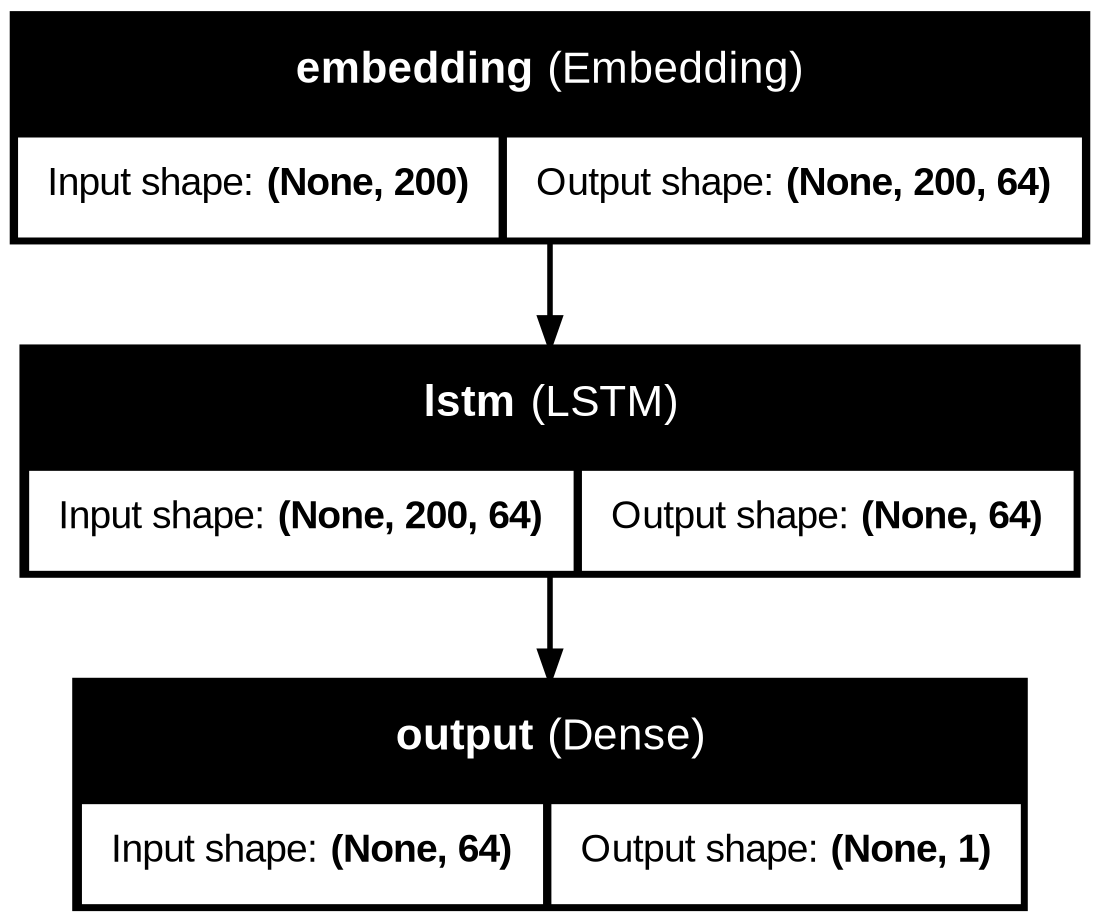

In [26]:
# ==================== PART C: BUILD THE LSTM MODEL ====================
student_info("PART C – LSTM model")

model = keras.Sequential([
    keras.Input(shape=(MAXLEN,), name="input_sequence"),           # padded sequences
    layers.Embedding(VOCAB_SIZE, EMBED_DIM, name="embedding"),     # word ids -> dense vectors
    layers.LSTM(LSTM_UNITS, name="lstm"),                          # learns word order / context
    layers.Dense(1, activation="sigmoid", name="output"),          # probability of positive review
], name="LSTM_Sentiment_Model")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

trainable = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
non_trainable = sum(int(np.prod(w.shape)) for w in model.non_trainable_weights)
print("\nTotal parameters         :", model.count_params())
print("Trainable parameters     :", trainable)
print("Non-trainable parameters :", non_trainable)
print("Optimizer: Adam | Loss: binary_crossentropy | Metric: accuracy")

# Optional: architecture diagram (skipped automatically if graphviz is not available)
try:
    from IPython.display import display
    display(keras.utils.plot_model(model, show_shapes=True, show_layer_names=True))
except Exception as e:
    print("Model diagram skipped:", type(e).__name__)

## PART D – MODEL TRAINING AND SENTIMENT PREDICTION

- The model is trained on the training set and validated on the validation set after every epoch.
- **EarlyStopping** stops training when the validation loss stops improving (patience = 2) and restores the best weights. This prevents overfitting from too many epochs.
- Accuracy and loss curves are plotted, then the model is evaluated on the unseen **test set** using accuracy, precision, recall, F1-score and a confusion matrix.
- Finally, sample reviews are passed through the same preprocessing pipeline and the predicted sentiment is compared with the actual sentiment.

All values below are produced by the code – nothing is typed in manually.

In [27]:
# ==================== PART D (1/5): TRAIN THE MODEL ====================
student_info("PART D – Model training")

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    callbacks=[early_stop],
                    verbose=2)

hist_df = pd.DataFrame(history.history)
hist_df.insert(0, "epoch", range(1, len(hist_df) + 1))
print("\n----- Training history (one row per epoch) -----")
print(hist_df.round(4).to_string(index=False))

best_epoch = int(hist_df["val_loss"].idxmin()) + 1
print("\nEpochs actually run       :", len(hist_df))
print("Best epoch (lowest val loss):", best_epoch)
print("Final epoch -> Training accuracy  :", round(hist_df['accuracy'].iloc[-1], 4))
print("Final epoch -> Validation accuracy:", round(hist_df['val_accuracy'].iloc[-1], 4))
print("Final epoch -> Training loss      :", round(hist_df['loss'].iloc[-1], 4))
print("Final epoch -> Validation loss    :", round(hist_df['val_loss'].iloc[-1], 4))

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART D – Model training
Run time   : 30-09-2026 12:36:04
Epoch 1/10
250/250 - 4s - 17ms/step - accuracy: 0.7771 - loss: 0.4556 - val_accuracy: 0.8685 - val_loss: 0.3316
Epoch 2/10
250/250 - 3s - 12ms/step - accuracy: 0.9068 - loss: 0.2445 - val_accuracy: 0.8555 - val_loss: 0.3503
Epoch 3/10
250/250 - 4s - 18ms/step - accuracy: 0.9211 - loss: 0.2108 - val_accuracy: 0.8677 - val_loss: 0.3731

----- Training history (one row per epoch) -----
 epoch  accuracy   loss  val_accuracy  val_loss
     1    0.7771 0.4556        0.8685    0.3316
     2    0.9068 0.2445        0.8555    0.3503
     3    0.9211 0.2108        0.8677    0.3731

Epochs actually run       : 3
Best epoch (lowest val loss): 1
Final epoch -> Training accuracy  : 0.9211
Final epoch -> Validation accuracy: 0.8677
Final epoch -> Training loss      : 0.2108
Final epoch -> Validation loss    : 0.3731


Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART D – Accuracy and loss plots
Run time   : 30-09-2026 12:36:16


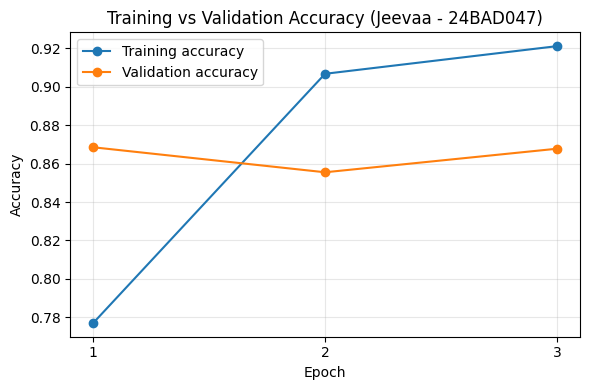

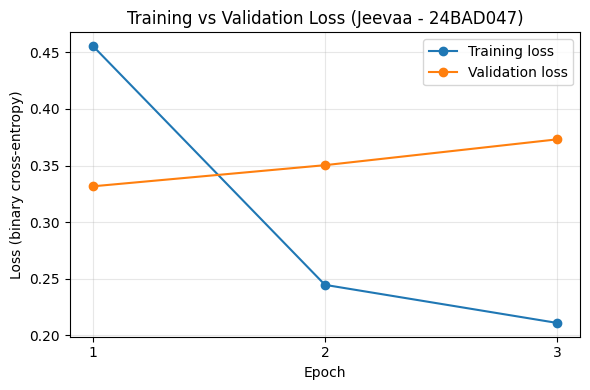

In [28]:
# ==================== PART D (2/5): ACCURACY AND LOSS GRAPHS ====================
student_info("PART D – Accuracy and loss plots")
os.makedirs("results", exist_ok=True)
epochs_range = range(1, len(history.history["accuracy"]) + 1)

# Plot 1: Accuracy vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(epochs_range, history.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Training vs Validation Accuracy (Jeevaa - 24BAD047)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.xticks(list(epochs_range))
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("results/accuracy_plot.png", dpi=150)
plt.show()

# Plot 2: Loss vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs_range, history.history["loss"], marker="o", label="Training loss")
plt.plot(epochs_range, history.history["val_loss"], marker="o", label="Validation loss")
plt.title("Training vs Validation Loss (Jeevaa - 24BAD047)")
plt.xlabel("Epoch"); plt.ylabel("Loss (binary cross-entropy)"); plt.xticks(list(epochs_range))
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("results/loss_plot.png", dpi=150)
plt.show()

In [29]:
# ==================== PART D (3/5): EVALUATE ON TEST DATA ====================
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
student_info("PART D – Evaluation on test data")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
y_prob = model.predict(X_test, verbose=0).ravel()      # probability of positive class
y_pred = (y_prob >= 0.5).astype(int)                   # threshold 0.5
y_true = y_test.astype(int)

metrics = {
    "Test loss": test_loss,
    "Accuracy": accuracy_score(y_true, y_pred),
    "Precision": precision_score(y_true, y_pred),
    "Recall": recall_score(y_true, y_pred),
    "F1-score": f1_score(y_true, y_pred),
}
print("\n----- FINAL TEST METRICS (positive class = 1) -----")
for name, value in metrics.items():
    print(f"{name:10s}: {value:.4f}")

print("\n----- Classification report -----")
print(classification_report(y_true, y_pred, target_names=["Negative", "Positive"], digits=4))

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART D – Evaluation on test data
Run time   : 30-09-2026 12:36:17

----- FINAL TEST METRICS (positive class = 1) -----
Test loss : 0.3601
Accuracy  : 0.8494
Precision : 0.8940
Recall    : 0.7907
F1-score  : 0.8392

----- Classification report -----
              precision    recall  f1-score   support

    Negative     0.8144    0.9074    0.8584      2515
    Positive     0.8940    0.7907    0.8392      2485

    accuracy                         0.8494      5000
   macro avg     0.8542    0.8491    0.8488      5000
weighted avg     0.8540    0.8494    0.8488      5000



Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART D – Confusion matrix
Run time   : 30-09-2026 12:36:19
Confusion matrix (rows = actual, columns = predicted):
[[2282  233]
 [ 520 1965]]

True Negatives : 2282   (negative predicted as negative)
False Positives: 233   (negative predicted as positive)
False Negatives: 520   (positive predicted as negative)
True Positives : 1965   (positive predicted as positive)


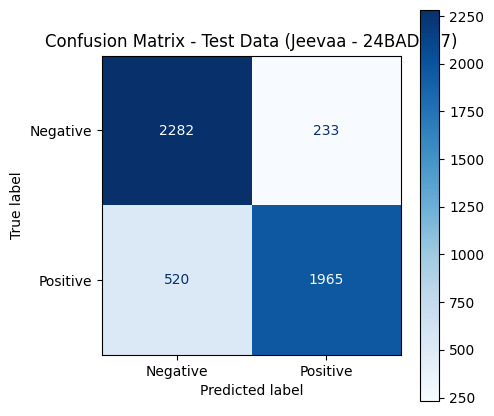

In [30]:
# ==================== PART D (4/5): CONFUSION MATRIX ====================
from sklearn.metrics import ConfusionMatrixDisplay
student_info("PART D – Confusion matrix")

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix (rows = actual, columns = predicted):")
print(cm)
print(f"\nTrue Negatives : {tn}   (negative predicted as negative)")
print(f"False Positives: {fp}   (negative predicted as positive)")
print(f"False Negatives: {fn}   (positive predicted as negative)")
print(f"True Positives : {tp}   (positive predicted as positive)")

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Confusion Matrix - Test Data (Jeevaa - 24BAD047)")
plt.tight_layout()
plt.savefig("results/confusion_matrix.png", dpi=150)
plt.show()

In [31]:
# ==================== PART D (5/5): SAMPLE SENTIMENT PREDICTIONS ====================
student_info("PART D – Sample sentiment predictions")

# (a) Our own example reviews (actual sentiment written by us)
custom_reviews = [
    ("This movie was absolutely wonderful, the acting was brilliant and I loved every minute of it.", "Positive"),
    ("A fantastic film with a touching story and great performances. Highly recommended!", "Positive"),
    ("One of the best movies I have seen this year, truly enjoyable and beautifully made.", "Positive"),
    ("This was a terrible film. The plot was boring and the acting was awful.", "Negative"),
    ("I hated this movie. A complete waste of time and money, very disappointing.", "Negative"),
    ("Worst movie ever, poorly written and painfully slow. I do not recommend it.", "Negative"),
    ("The visuals were beautiful but the story was dull and the ending was disappointing.", "Mixed"),
]
custom_prob = model.predict(encode_texts([r for r, _ in custom_reviews]), verbose=0).ravel()

rows = []
for (review, actual), p in zip(custom_reviews, custom_prob):
    pred = "Positive" if p >= 0.5 else "Negative"
    rows.append({"Source": "Custom", "Review": review[:70] + "...", "Actual": actual,
                 "Predicted": pred, "Probability": round(float(p), 4)})

# (b) Random reviews from the real test set (true labels come from the dataset)
rng = np.random.RandomState(SEED)
for i in rng.choice(len(test_df), size=5, replace=False):
    actual = "Positive" if y_true[i] == 1 else "Negative"
    pred = "Positive" if y_prob[i] >= 0.5 else "Negative"
    rows.append({"Source": "Test set", "Review": re.sub(r"<[^>]+>", " ", test_df["review"][i])[:70] + "...", "Actual": actual,
                 "Predicted": pred, "Probability": round(float(y_prob[i]), 4)})

pred_table = pd.DataFrame(rows)
pred_table["Match"] = np.where(pred_table["Actual"] == "Mixed", "n/a (mixed)",
                       np.where(pred_table["Actual"] == pred_table["Predicted"], "Correct", "Wrong"))

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)
print("Probability = model's probability that the review is POSITIVE (>= 0.5 -> Positive)\n")
print(pred_table.to_string(index=False))

pred_table.to_csv("results/sample_predictions.csv", index=False)
print("\nSaved: results/sample_predictions.csv")

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : PART D – Sample sentiment predictions
Run time   : 30-09-2026 12:36:19
Probability = model's probability that the review is POSITIVE (>= 0.5 -> Positive)

  Source                                                                    Review   Actual Predicted  Probability       Match
  Custom This movie was absolutely wonderful, the acting was brilliant and I lo... Positive  Positive       0.5369     Correct
  Custom A fantastic film with a touching story and great performances. Highly ... Positive  Positive       0.9135     Correct
  Custom One of the best movies I have seen this year, truly enjoyable and beau... Positive  Positive       0.6494     Correct
  Custom This was a terrible film. The plot was boring and the acting was awful... Negative  Negative       0.0241     Correct
  Custom I hated this movie. A complete waste of time and money, very disappoin... Ne

In [32]:
# ==================== OPTIONAL: WORD VECTORS AFTER TRAINING ====================
student_info("Optional - trained embedding space")
trained_table = model.get_layer("embedding").get_weights()[0]

def similar_words(word, top_n=5):
    if word not in word_index:
        return None
    v = trained_table[word_index[word]]
    norms = np.linalg.norm(trained_table, axis=1) * np.linalg.norm(v) + 1e-9
    sims = trained_table @ v / norms
    best = [i for i in np.argsort(-sims) if i > 1 and i != word_index[word]][:top_n]
    return [(index_word[i], round(float(sims[i]), 3)) for i in best]

for w in ["good", "bad"]:
    print(f"Words closest to '{w}' after training:", similar_words(w))

if "good" in word_index and "great" in word_index:
    print("\nCosine similarity(good, great) AFTER training:",
          round(cosine(trained_table[word_index["good"]], trained_table[word_index["great"]]), 4))

student_info("Experiment completed")
print("Files saved in the 'results' folder:", os.listdir("results"))

Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : Optional - trained embedding space
Run time   : 30-09-2026 12:36:19
Words closest to 'good' after training: [('freedom', 0.779), ('favorite', 0.778), ('novak', 0.778), ('wonderful', 0.773), ('hook', 0.767)]
Words closest to 'bad' after training: [('horrible', 0.936), ('worst', 0.93), ('waste', 0.921), ('awful', 0.915), ('dull', 0.911)]

Cosine similarity(good, great) AFTER training: 0.7129
Name       : Jeevanantham K
Roll No    : 24BAD047
Department : AI & DS
Experiment : 6 – LSTM Sentiment Analysis
Section    : Experiment completed
Run time   : 30-09-2026 12:36:19
Files saved in the 'results' folder: ['sample_predictions.csv', 'confusion_matrix.png', 'accuracy_plot.png', 'loss_plot.png']


## RESULT
The LSTM model was built, trained and evaluated successfully on the IMDB movie review dataset. The final test accuracy, precision, recall, F1-score and confusion matrix are printed by the evaluation cells above.

## EXPECTED OUTCOME
Text preprocessing, tokenization, sequence padding and embedding generation were performed using NLP libraries. An LSTM network was trained to learn sequential information from movie reviews and classify them as positive or negative.